In [1]:
!chcp 65001

Active code page: 65001


In [1]:
cd "../회사 자료"

c:\Users\greenfesco\Desktop\회사 자료


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_1560\161864411.py:175: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged[f'{col}_lag{lag}'] = merged.groupby('device_sn')[col].shift(lag)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_1560\161864411.py:175: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged[f'{col}_lag{lag}'] = merged.groupby('device_sn')[col].shift(lag)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_1560\161864411.py:175: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to re

[LightGBM] [Info] Number of positive: 96639, number of negative: 72210
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009772 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5704
[LightGBM] [Info] Number of data points in the train set: 168849, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.572340 -> initscore=0.291404
[LightGBM] [Info] Start training from score 0.291404

===== ZERO / NON-ZERO CLASSIFICATION =====
Accuracy: 0.9929418488355479
F1 Score: 0.9863829318043994
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008706 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5672
[LightGBM] [Info] Number of data points in the train set: 96639, number of used features: 42
[LightGBM] [Info] Start training from score 0.395755

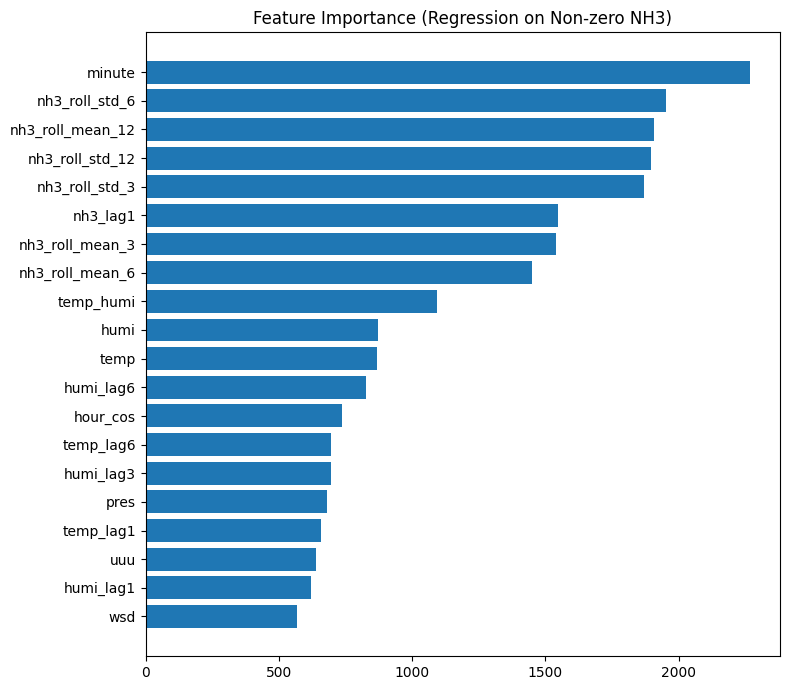


=== CLASSIFICATION FEATURE IMPORTANCE ===
             feature  importance
14            minute        2156
40         temp_humi         887
38  nh3_roll_mean_12         703
24         temp_lag6         691
1               humi         690
27         humi_lag6         669
23         temp_lag3         588
22         temp_lag1         554
0               temp         521
31          nh3_lag1         451
26         humi_lag3         448
30         pres_lag6         434
25         humi_lag1         432
7                tmp         430
39   nh3_roll_std_12         429
9                uuu         388
10               vvv         373
2               pres         364
11               vec         350
29         pres_lag3         349


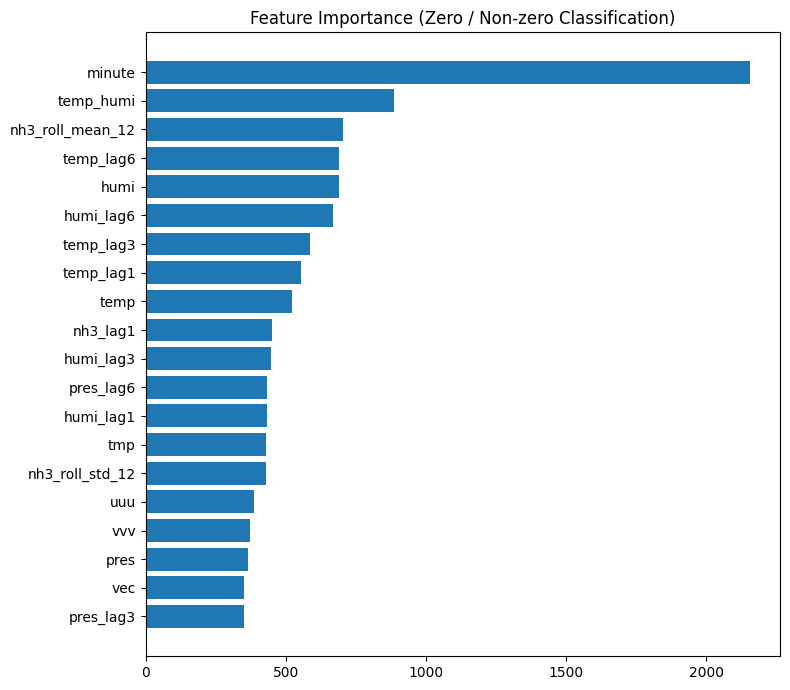

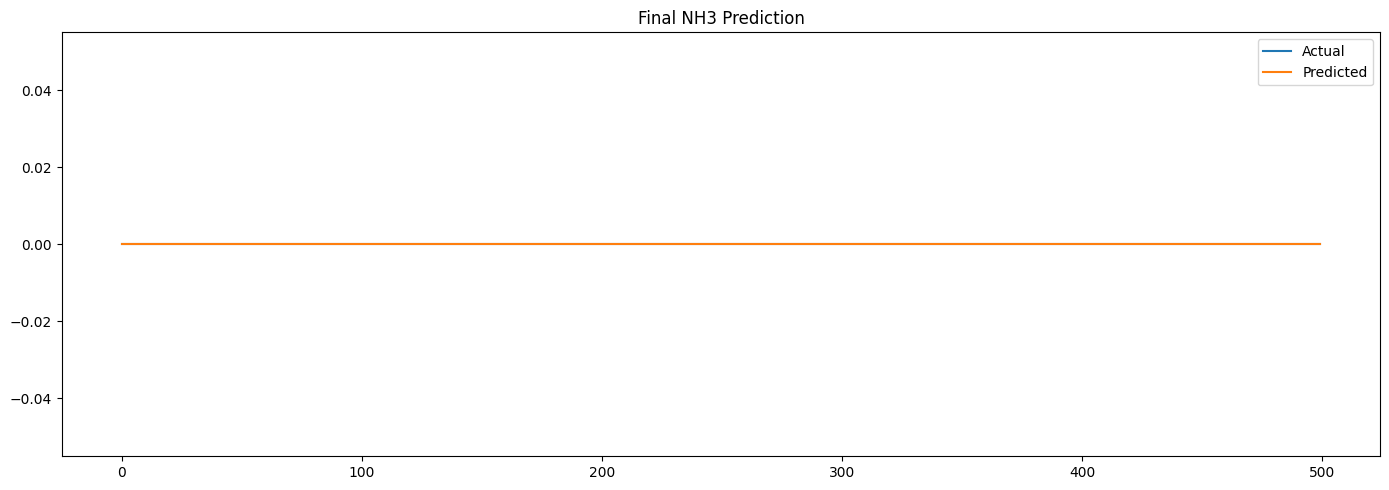


=== RESULT SAMPLE ===
             timestamp  device_sn  nh3_cv  pred  is_actual_nonzero  \
0  2024-05-27 13:45:00  SP_KH_D01     0.0   0.0                  0   
1  2024-05-27 13:46:00  SP_KH_D01     0.0   0.0                  0   
2  2024-05-27 13:47:00  SP_KH_D01     0.0   0.0                  0   
3  2024-05-27 13:48:00  SP_KH_D01     0.0   0.0                  0   
4  2024-05-27 13:49:00  SP_KH_D01     0.0   0.0                  0   
5  2024-05-27 13:50:00  SP_KH_D01     0.0   0.0                  0   
6  2024-05-27 13:51:00  SP_KH_D01     0.0   0.0                  0   
7  2024-05-27 13:52:00  SP_KH_D01     0.0   0.0                  0   
8  2024-05-27 13:53:00  SP_KH_D01     0.0   0.0                  0   
9  2024-05-27 13:54:00  SP_KH_D01     0.0   0.0                  0   
10 2024-05-27 13:55:00  SP_KH_D01     0.0   0.0                  0   
11 2024-05-27 13:56:00  SP_KH_D01     0.0   0.0                  0   
12 2024-05-27 13:57:00  SP_KH_D01     0.0   0.0                  0 

In [15]:
import pandas as pd
import numpy as np
import re
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score

# =========================================================
# 0. 파일 경로
# =========================================================
sensor_path = './암모니아 농도 예측 폴더/암모니아데이터_24-07-29-13시.csv'
weather_path = './암모니아 농도 예측 폴더/암모니아날씨데이터_24-07-29-13시.csv'

# =========================================================
# 1. 설정
# =========================================================
target_col = 'nh3_cv'
test_device = 'SP_KH_D01'

weather_lags = [1, 3, 6]
nh3_lags = [1, 3, 6]
zero_threshold = 0.05   # 0 / non-zero 분리 기준
random_state = 42

# =========================================================
# 2. 강수량 변환
# =========================================================
def convert_pcp(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value in ['강수없음', '없음', '0', '0.0', '0mm', '0.0mm']:
        return 0.0

    nums = re.findall(r'\d+\.?\d*', value)
    if nums:
        return float(nums[0])

    return np.nan

# =========================================================
# 3. 평가 함수
# =========================================================
def eval_metrics(y, p, title="RESULT"):
    rmse = np.sqrt(mean_squared_error(y, p))
    mae = mean_absolute_error(y, p)
    r2 = r2_score(y, p)

    print(f"\n===== {title} =====")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

def eval_nonzero_metrics(y, p, threshold=0.05):
    mask = y > threshold
    print("\n===== NON-ZERO ONLY =====")
    print("Count:", mask.sum())

    if mask.sum() == 0:
        print("No non-zero samples in test set.")
        return

    rmse = np.sqrt(mean_squared_error(y[mask], p[mask]))
    mae = mean_absolute_error(y[mask], p[mask])
    r2 = r2_score(y[mask], p[mask])

    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

# =========================================================
# 4. 데이터 로드
# =========================================================
sensor_df = pd.read_csv(sensor_path)
weather_df = pd.read_csv(weather_path)

# =========================================================
# 5. 시간 처리
# =========================================================
sensor_df['crt_dttm'] = pd.to_datetime(sensor_df['crt_dttm'])
sensor_df['timestamp'] = sensor_df['crt_dttm'].dt.floor('min')

weather_df['fcst_datetime'] = pd.to_datetime(
    weather_df['fcst_date'].astype(str) + weather_df['fcst_time'].astype(str).str.zfill(4),
    format='%Y%m%d%H%M'
)

# =========================================================
# 6. 날씨 데이터 1분 단위 확장
#    FutureWarning 안 뜨게 groupby.apply 대신 반복 처리
# =========================================================
weather_resampled_list = []

for sn, g in weather_df.sort_values(['sn', 'fcst_datetime']).groupby('sn'):
    g = g.sort_values('fcst_datetime').set_index('fcst_datetime').resample('min').ffill()
    g['sn'] = sn
    weather_resampled_list.append(g.reset_index())

weather_df = pd.concat(weather_resampled_list, ignore_index=True)
weather_df['timestamp'] = weather_df['fcst_datetime']

# =========================================================
# 7. 매핑
# =========================================================
device_map = {
    'SP_KH_D01': 'KH_WM_01',
    'SP_KH_D02': 'KH_WM_01',
    'SP_SB_D02': 'SB_WM_01',
    'SP_SB_D03': 'SB_WM_01',
}

sensor_df['weather_sn'] = sensor_df['device_sn'].map(device_map)

# =========================================================
# 8. 날씨 전처리
# =========================================================
weather_df['pcp'] = weather_df['pcp'].apply(convert_pcp)

# =========================================================
# 9. 병합
# =========================================================
merged = pd.merge(
    sensor_df,
    weather_df,
    left_on=['timestamp', 'weather_sn'],
    right_on=['timestamp', 'sn'],
    how='inner'
)

# =========================================================
# 10. 컬럼 정리
# =========================================================
drop_cols = [
    'sensor_data_id', 'use_yn', 'crt_usr_id',
    'weather_info_id', 'fcst_date', 'fcst_time',
    'sn', 'weather_sn'
]

merged = merged.drop(columns=[c for c in drop_cols if c in merged.columns], errors='ignore')

# =========================================================
# 11. 정렬
# =========================================================
merged = merged.sort_values(['device_sn', 'timestamp']).reset_index(drop=True)

# =========================================================
# 12. 시간 파생
# =========================================================
merged['hour'] = merged['timestamp'].dt.hour
merged['dayofweek'] = merged['timestamp'].dt.dayofweek
merged['month'] = merged['timestamp'].dt.month
merged['minute'] = merged['timestamp'].dt.minute

merged['hour_sin'] = np.sin(2 * np.pi * merged['hour'] / 24)
merged['hour_cos'] = np.cos(2 * np.pi * merged['hour'] / 24)
merged['dayofweek_sin'] = np.sin(2 * np.pi * merged['dayofweek'] / 7)
merged['dayofweek_cos'] = np.cos(2 * np.pi * merged['dayofweek'] / 7)

# =========================================================
# 13. 장비 정보 추가
# =========================================================
merged['device_sn'] = merged['device_sn'].astype('category')

# =========================================================
# 14. lag feature 생성
#    - weather/sensor lag
#    - NH3 lag 추가 (핵심)
# =========================================================
for lag in weather_lags:
    for col in ['temp', 'humi', 'pres']:
        if col in merged.columns:
            merged[f'{col}_lag{lag}'] = merged.groupby('device_sn')[col].shift(lag)

for lag in nh3_lags:
    merged[f'nh3_lag{lag}'] = merged.groupby('device_sn')[target_col].shift(lag)

# =========================================================
# 15. rolling feature 추가
# =========================================================
for window in [3, 6, 12]:
    merged[f'nh3_roll_mean_{window}'] = (
        merged.groupby('device_sn')[target_col]
        .shift(1)
        .rolling(window=window)
        .mean()
    )
    merged[f'nh3_roll_std_{window}'] = (
        merged.groupby('device_sn')[target_col]
        .shift(1)
        .rolling(window=window)
        .std()
    )

# =========================================================
# 16. interaction feature 추가
# =========================================================
if 'temp' in merged.columns and 'humi' in merged.columns:
    merged['temp_humi'] = merged['temp'] * merged['humi']

if 'tmp' in merged.columns and 'reh' in merged.columns:
    merged['tmp_reh'] = merged['tmp'] * merged['reh']

# =========================================================
# 17. feature 정의
# =========================================================
feature_cols = [
    # 현재 센서/기상
    'temp', 'humi', 'pres',
    'pty', 'pcp', 'pop', 'sky', 'tmp', 'reh',
    'uuu', 'vvv', 'vec', 'wsd',

    # 시간
    'hour', 'minute', 'dayofweek', 'month',
    'hour_sin', 'hour_cos',
    'dayofweek_sin', 'dayofweek_cos',

    # 장비
    'device_sn',

    # lag
    'temp_lag1', 'temp_lag3', 'temp_lag6',
    'humi_lag1', 'humi_lag3', 'humi_lag6',
    'pres_lag1', 'pres_lag3', 'pres_lag6',

    # NH3 lag
    'nh3_lag1', 'nh3_lag3', 'nh3_lag6',

    # rolling
    'nh3_roll_mean_3', 'nh3_roll_std_3',
    'nh3_roll_mean_6', 'nh3_roll_std_6',
    'nh3_roll_mean_12', 'nh3_roll_std_12',

    # interaction
    'temp_humi', 'tmp_reh',
]

feature_cols = [c for c in feature_cols if c in merged.columns]

# =========================================================
# 18. 결측 제거
# =========================================================
merged = merged.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

# 타겟 음수 방지
merged[target_col] = merged[target_col].clip(lower=0)

# =========================================================
# 19. train/test 분리 (장비 기준)
# =========================================================
train_df = merged[merged['device_sn'] != test_device].copy()
test_df  = merged[merged['device_sn'] == test_device].copy()

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

categorical_cols = ['device_sn']

# =========================================================
# 20. 1단계: zero / non-zero 분류
# =========================================================
y_train_cls = (y_train > zero_threshold).astype(int)
y_test_cls = (y_test > zero_threshold).astype(int)

clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    objective='binary',
    random_state=random_state
)

clf.fit(
    X_train,
    y_train_cls,
    categorical_feature=categorical_cols
)

cls_probs = clf.predict_proba(X_test)[:, 1]
cls_preds = (cls_probs >= 0.5).astype(int)

print("\n===== ZERO / NON-ZERO CLASSIFICATION =====")
print("Accuracy:", accuracy_score(y_test_cls, cls_preds))
print("F1 Score:", f1_score(y_test_cls, cls_preds, zero_division=0))

# =========================================================
# 21. 2단계: non-zero 구간 회귀 (log1p)
# =========================================================
reg_train_mask = y_train > zero_threshold

X_train_reg = X_train.loc[reg_train_mask].copy()
y_train_reg = y_train.loc[reg_train_mask].copy()

# log transform
y_train_reg_log = np.log1p(y_train_reg)

reg = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=random_state
)

reg.fit(
    X_train_reg,
    y_train_reg_log,
    categorical_feature=categorical_cols
)

# =========================================================
# 22. 최종 예측
#    분류기에서 non-zero라고 본 경우만 회귀값 사용
# =========================================================
reg_preds_log = reg.predict(X_test)
reg_preds = np.expm1(reg_preds_log)
reg_preds = np.clip(reg_preds, 0, None)

final_preds = np.where(cls_preds == 1, reg_preds, 0.0)

# =========================================================
# 23. 평가
# =========================================================
eval_metrics(y_test, final_preds, title="FINAL NH3 PREDICTION")
eval_nonzero_metrics(y_test.values, final_preds, threshold=zero_threshold)

# baseline 비교
baseline_zero = np.zeros_like(y_test.values)
eval_metrics(y_test, baseline_zero, title="ZERO BASELINE")

# =========================================================
# 24. 중요도
# =========================================================
imp_reg = pd.DataFrame({
    'feature': feature_cols,
    'importance': reg.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== REGRESSION FEATURE IMPORTANCE ===")
print(imp_reg.head(20))

plt.figure(figsize=(8, 7))
plt.barh(imp_reg['feature'].head(20)[::-1], imp_reg['importance'].head(20)[::-1])
plt.title("Feature Importance (Regression on Non-zero NH3)")
plt.tight_layout()
plt.show()

imp_clf = pd.DataFrame({
    'feature': feature_cols,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== CLASSIFICATION FEATURE IMPORTANCE ===")
print(imp_clf.head(20))

plt.figure(figsize=(8, 7))
plt.barh(imp_clf['feature'].head(20)[::-1], imp_clf['importance'].head(20)[::-1])
plt.title("Feature Importance (Zero / Non-zero Classification)")
plt.tight_layout()
plt.show()

# =========================================================
# 25. 시각화
# =========================================================
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:500], label='Actual')
plt.plot(final_preds[:500], label='Predicted')
plt.legend()
plt.title("Final NH3 Prediction")
plt.tight_layout()
plt.show()

# =========================================================
# 26. 결과 확인용 데이터프레임
# =========================================================
result_df = test_df[['timestamp', 'device_sn', target_col]].copy()
result_df['pred'] = final_preds
result_df['is_actual_nonzero'] = (result_df[target_col] > zero_threshold).astype(int)
result_df['is_pred_nonzero'] = cls_preds
result_df['nonzero_prob'] = cls_probs

print("\n=== RESULT SAMPLE ===")
print(result_df.head(20))

# lag와 rolling으로 다음 1분 예측하기


================ BEFORE MERGE ================
Test raw rows: 35038

===== SP_KH_D01 RAW TARGET SUMMARY =====
count    35038.000000
mean         0.069385
std          1.100670
min          0.000000
25%          0.000000
50%          0.000000
75%          0.100000
max         50.000000
Name: nh3_cv, dtype: float64
non-zero ratio (>0): 0.26237228152291797
max: 50.0

================ AFTER FEATURE ENGINEERING ================
Rows before dropna: 203892
Rows after  dropna: 203844

================ AFTER MERGE & DROPNA ================
Test rows after merge/dropna: 34995

===== SP_KH_D01 MERGED TARGET SUMMARY =====
count    34995.000000
mean         0.043718
std          0.088090
min          0.000000
25%          0.000000
50%          0.000000
75%          0.100000
max          0.700000
Name: nh3_cv, dtype: float64
non-zero ratio (>0): 0.2619802828975568
max: 0.7

================ PER DEVICE SUMMARY ================

[SP_KH_D01]
rows: 34995
target mean: 0.04371767395342192
target max : 0.

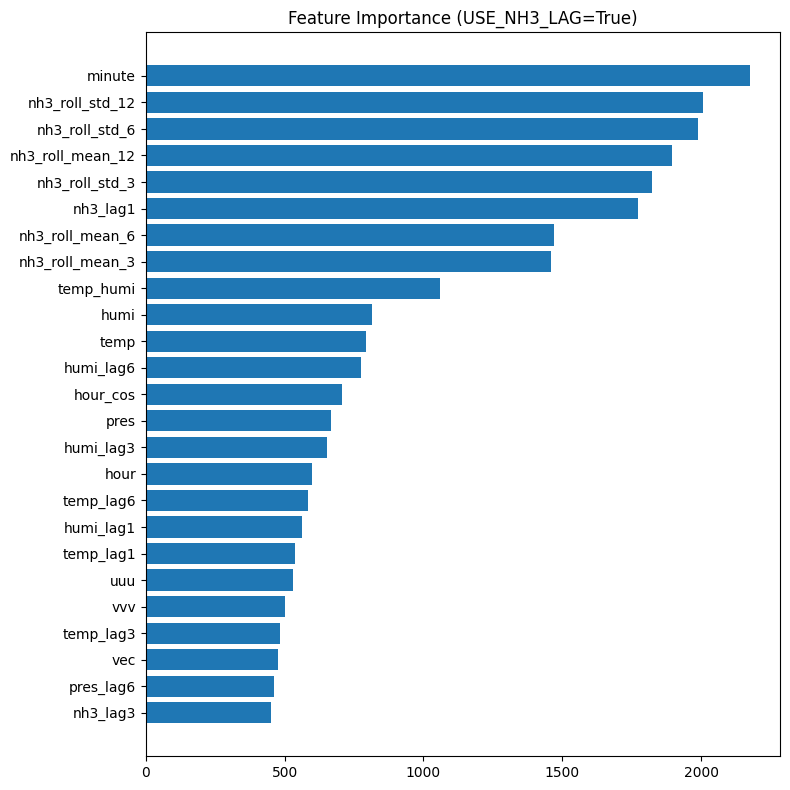

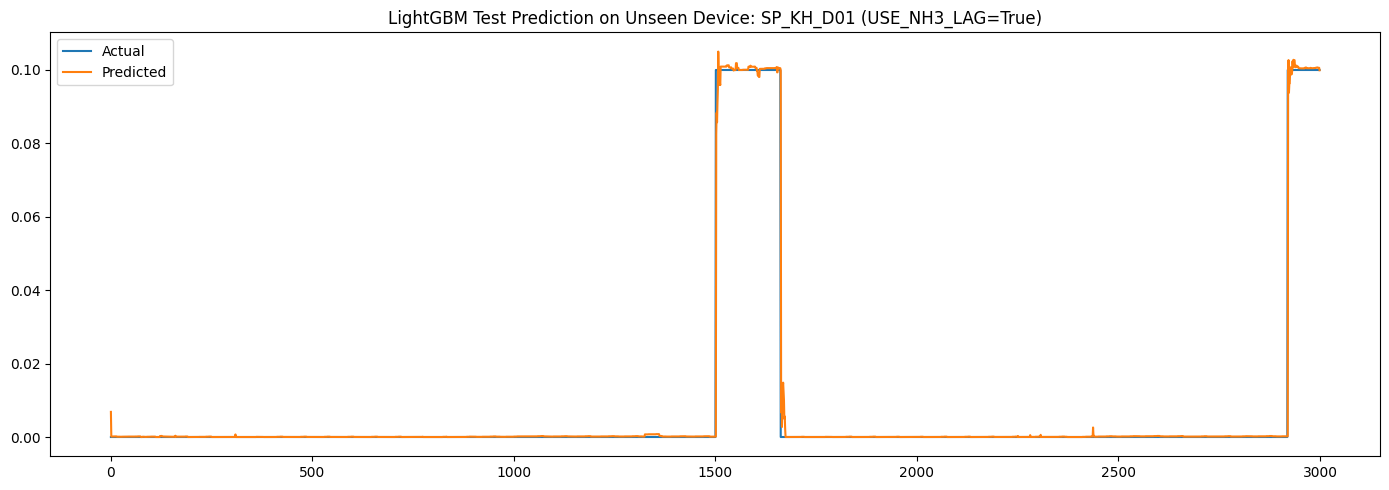

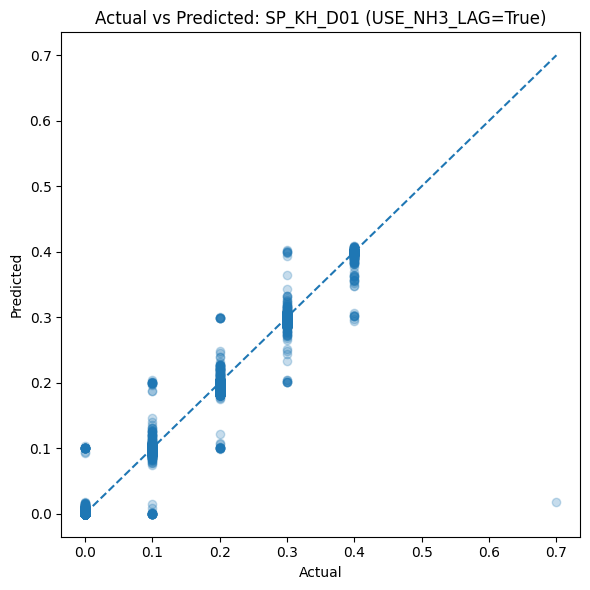


===== RESULT SAMPLE =====
             timestamp  device_sn  nh3_cv      pred     error  abs_error
0  2024-05-27 13:45:00  SP_KH_D01     0.0  0.006845  0.006845   0.006845
1  2024-05-27 13:46:00  SP_KH_D01     0.0  0.000127  0.000127   0.000127
2  2024-05-27 13:47:00  SP_KH_D01     0.0  0.000127  0.000127   0.000127
3  2024-05-27 13:48:00  SP_KH_D01     0.0  0.000127  0.000127   0.000127
4  2024-05-27 13:49:00  SP_KH_D01     0.0  0.000127  0.000127   0.000127
5  2024-05-27 13:50:00  SP_KH_D01     0.0  0.000115  0.000115   0.000115
6  2024-05-27 13:51:00  SP_KH_D01     0.0  0.000115  0.000115   0.000115
7  2024-05-27 13:52:00  SP_KH_D01     0.0  0.000127  0.000127   0.000127
8  2024-05-27 13:53:00  SP_KH_D01     0.0  0.000150  0.000150   0.000150
9  2024-05-27 13:54:00  SP_KH_D01     0.0  0.000162  0.000162   0.000162
10 2024-05-27 13:55:00  SP_KH_D01     0.0  0.000162  0.000162   0.000162
11 2024-05-27 13:56:00  SP_KH_D01     0.0  0.000162  0.000162   0.000162
12 2024-05-27 13:57:00  

In [16]:
import pandas as pd
import numpy as np
import re
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================================================
# 0. 파일 경로
# =========================================================
sensor_path = './암모니아 농도 예측 폴더/암모니아데이터_24-07-29-13시.csv'
weather_path = './암모니아 농도 예측 폴더/암모니아날씨데이터_24-07-29-13시.csv'

# =========================================================
# 1. 설정
# =========================================================
target_col = 'nh3_cv'
test_device = 'SP_KH_D01'
random_state = 42

weather_lags = [1, 3, 6]
nh3_lags = [1, 3, 6]
rolling_windows = [3, 6, 12]

USE_NH3_LAG = True   # True: nh3 lag/rolling 포함, False: 제외
PLOT_N = 3000        # 시각화 길이

# =========================================================
# 2. 유틸 함수
# =========================================================
def convert_pcp(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value in ['강수없음', '없음', '0', '0.0', '0mm', '0.0mm']:
        return 0.0

    nums = re.findall(r'\d+\.?\d*', value)
    if nums:
        return float(nums[0])

    return np.nan


def eval_metrics(y_true, y_pred, title="RESULT"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n===== {title} =====")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)


def print_target_summary(df, target_col, name):
    print(f"\n===== {name} TARGET SUMMARY =====")
    print(df[target_col].describe())
    print("non-zero ratio (>0):", (df[target_col] > 0).mean())
    print("max:", df[target_col].max())


def plot_predictions(y_true, y_pred, title, n=3000):
    n = min(n, len(y_true))
    plt.figure(figsize=(14, 5))
    plt.plot(y_true[:n], label='Actual')
    plt.plot(y_pred[:n], label='Predicted')
    plt.legend()
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_scatter(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.25)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(title)

    min_v = min(np.min(y_true), np.min(y_pred))
    max_v = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_v, max_v], [min_v, max_v], linestyle='--')
    plt.tight_layout()
    plt.show()


# =========================================================
# 3. 데이터 로드
# =========================================================
sensor_df = pd.read_csv(sensor_path)
weather_df = pd.read_csv(weather_path)

# =========================================================
# 4. 시간 처리
# =========================================================
sensor_df['crt_dttm'] = pd.to_datetime(sensor_df['crt_dttm'])
sensor_df['timestamp'] = sensor_df['crt_dttm'].dt.floor('min')

weather_df['fcst_datetime'] = pd.to_datetime(
    weather_df['fcst_date'].astype(str) + weather_df['fcst_time'].astype(str).str.zfill(4),
    format='%Y%m%d%H%M'
)

# =========================================================
# 5. 장비-날씨 매핑
# =========================================================
device_map = {
    'SP_KH_D01': 'KH_WM_01',
    'SP_KH_D02': 'KH_WM_01',
    'SP_SB_D02': 'SB_WM_01',
    'SP_SB_D03': 'SB_WM_01',
}
sensor_df['weather_sn'] = sensor_df['device_sn'].map(device_map)

# =========================================================
# 6. 날씨 전처리
# =========================================================
weather_df['pcp'] = weather_df['pcp'].apply(convert_pcp)

# 범주형 텍스트일 수 있으면 숫자로 정리
for col in ['pty', 'pop', 'sky', 'tmp', 'reh', 'uuu', 'vvv', 'vec', 'wsd']:
    if col in weather_df.columns:
        weather_df[col] = pd.to_numeric(weather_df[col], errors='coerce')

for col in ['temp', 'humi', 'pres', target_col]:
    if col in sensor_df.columns:
        sensor_df[col] = pd.to_numeric(sensor_df[col], errors='coerce')

# 타겟 음수 방지
sensor_df[target_col] = sensor_df[target_col].clip(lower=0)

# =========================================================
# 7. 날씨 1분 단위 확장
# =========================================================
weather_resampled_list = []

for sn, g in weather_df.sort_values(['sn', 'fcst_datetime']).groupby('sn'):
    g = g.sort_values('fcst_datetime').set_index('fcst_datetime').resample('min').ffill()
    g['sn'] = sn
    weather_resampled_list.append(g.reset_index())

weather_df_1min = pd.concat(weather_resampled_list, ignore_index=True)
weather_df_1min['timestamp'] = weather_df_1min['fcst_datetime']

# =========================================================
# 8. 병합 전 테스트 장비 분포 확인
# =========================================================
sensor_test_raw = sensor_df[sensor_df['device_sn'] == test_device].copy()

print("\n================ BEFORE MERGE ================")
print("Test raw rows:", len(sensor_test_raw))
if len(sensor_test_raw) > 0:
    print_target_summary(sensor_test_raw, target_col, f"{test_device} RAW")

# =========================================================
# 9. 병합
# =========================================================
merged = pd.merge(
    sensor_df,
    weather_df_1min,
    left_on=['timestamp', 'weather_sn'],
    right_on=['timestamp', 'sn'],
    how='inner'
)

# =========================================================
# 10. 불필요 컬럼 제거
# =========================================================
drop_cols = [
    'sensor_data_id', 'use_yn', 'crt_usr_id',
    'weather_info_id', 'fcst_date', 'fcst_time',
    'sn', 'weather_sn', 'fcst_datetime'
]

merged = merged.drop(columns=[c for c in drop_cols if c in merged.columns], errors='ignore')

# =========================================================
# 11. 정렬
# =========================================================
merged = merged.sort_values(['device_sn', 'timestamp']).reset_index(drop=True)

# =========================================================
# 12. 시간 파생
# =========================================================
merged['hour'] = merged['timestamp'].dt.hour
merged['minute'] = merged['timestamp'].dt.minute
merged['dayofweek'] = merged['timestamp'].dt.dayofweek
merged['month'] = merged['timestamp'].dt.month

merged['hour_sin'] = np.sin(2 * np.pi * merged['hour'] / 24)
merged['hour_cos'] = np.cos(2 * np.pi * merged['hour'] / 24)
merged['dayofweek_sin'] = np.sin(2 * np.pi * merged['dayofweek'] / 7)
merged['dayofweek_cos'] = np.cos(2 * np.pi * merged['dayofweek'] / 7)

# =========================================================
# 13. lag feature 생성
#    주의: groupby 후 rolling은 transform으로 맞춰주는 게 안전함
# =========================================================
for lag in weather_lags:
    for col in ['temp', 'humi', 'pres', 'tmp', 'reh', 'wsd', 'sky']:
        if col in merged.columns:
            merged[f'{col}_lag{lag}'] = merged.groupby('device_sn')[col].shift(lag)

if USE_NH3_LAG:
    for lag in nh3_lags:
        merged[f'nh3_lag{lag}'] = merged.groupby('device_sn')[target_col].shift(lag)

    for window in rolling_windows:
        merged[f'nh3_roll_mean_{window}'] = (
            merged.groupby('device_sn')[target_col]
            .transform(lambda s: s.shift(1).rolling(window=window, min_periods=window).mean())
        )
        merged[f'nh3_roll_std_{window}'] = (
            merged.groupby('device_sn')[target_col]
            .transform(lambda s: s.shift(1).rolling(window=window, min_periods=window).std())
        )

# =========================================================
# 14. interaction feature
# =========================================================
if 'temp' in merged.columns and 'humi' in merged.columns:
    merged['temp_humi'] = merged['temp'] * merged['humi']

if 'tmp' in merged.columns and 'reh' in merged.columns:
    merged['tmp_reh'] = merged['tmp'] * merged['reh']

# =========================================================
# 15. feature 정의
#    unseen device generalization 목적이라 device_sn 제외
# =========================================================
feature_cols = [
    # 현재 센서/기상
    'temp', 'humi', 'pres',
    'pty', 'pcp', 'pop', 'sky', 'tmp', 'reh',
    'uuu', 'vvv', 'vec', 'wsd',

    # 시간
    'hour', 'minute', 'dayofweek', 'month',
    'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos',

    # weather lag
    'temp_lag1', 'temp_lag3', 'temp_lag6',
    'humi_lag1', 'humi_lag3', 'humi_lag6',
    'pres_lag1', 'pres_lag3', 'pres_lag6',
    'tmp_lag1', 'tmp_lag3', 'tmp_lag6',
    'reh_lag1', 'reh_lag3', 'reh_lag6',
    'wsd_lag1', 'wsd_lag3', 'wsd_lag6',
    'sky_lag1', 'sky_lag3', 'sky_lag6',

    # interaction
    'temp_humi', 'tmp_reh',
]

if USE_NH3_LAG:
    feature_cols += [
        'nh3_lag1', 'nh3_lag3', 'nh3_lag6',
        'nh3_roll_mean_3', 'nh3_roll_std_3',
        'nh3_roll_mean_6', 'nh3_roll_std_6',
        'nh3_roll_mean_12', 'nh3_roll_std_12',
    ]

feature_cols = [c for c in feature_cols if c in merged.columns]

# =========================================================
# 16. 결측 제거
# =========================================================
before_drop = len(merged)
merged = merged.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)
after_drop = len(merged)

print("\n================ AFTER FEATURE ENGINEERING ================")
print("Rows before dropna:", before_drop)
print("Rows after  dropna:", after_drop)

# =========================================================
# 17. 병합 후 테스트 장비 분포 확인
# =========================================================
test_after = merged[merged['device_sn'] == test_device].copy()

print("\n================ AFTER MERGE & DROPNA ================")
print("Test rows after merge/dropna:", len(test_after))
if len(test_after) > 0:
    print_target_summary(test_after, target_col, f"{test_device} MERGED")

print("\n================ PER DEVICE SUMMARY ================")
for dev in sorted(merged['device_sn'].dropna().unique()):
    g = merged[merged['device_sn'] == dev]
    print(f"\n[{dev}]")
    print("rows:", len(g))
    print("target mean:", g[target_col].mean())
    print("target max :", g[target_col].max())
    print("non-zero ratio (>0):", (g[target_col] > 0).mean())

# =========================================================
# 18. train/test 분리 (장비 기준)
# =========================================================
train_df = merged[merged['device_sn'] != test_device].copy()
test_df = merged[merged['device_sn'] == test_device].copy()

print("\n================ TRAIN / TEST SPLIT ================")
print("Train rows:", len(train_df))
print("Test  rows:", len(test_df))

if len(test_df) == 0:
    raise ValueError("test_df가 비어 있음. 병합 또는 dropna 과정에서 테스트 장비 데이터가 사라졌는지 확인 필요.")

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

# =========================================================
# 19. 모델 학습
#    log1p 타겟 회귀
# =========================================================
y_train_log = np.log1p(y_train)

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=random_state
)

model.fit(X_train, y_train_log)

# =========================================================
# 20. 예측
# =========================================================
pred_train_log = model.predict(X_train)
pred_test_log = model.predict(X_test)

pred_train = np.expm1(pred_train_log)
pred_test = np.expm1(pred_test_log)

pred_train = np.clip(pred_train, 0, None)
pred_test = np.clip(pred_test, 0, None)

# =========================================================
# 21. 평가
# =========================================================
eval_metrics(y_train, pred_train, title="TRAIN")
eval_metrics(y_test, pred_test, title=f"TEST (UNSEEN DEVICE: {test_device})")

# 0 baseline
zero_baseline = np.zeros_like(y_test.values)
eval_metrics(y_test, zero_baseline, title="ZERO BASELINE")

# =========================================================
# 22. 중요도
# =========================================================
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n===== FEATURE IMPORTANCE =====")
print(imp_df.head(30))

plt.figure(figsize=(8, 8))
topn = min(25, len(imp_df))
plt.barh(imp_df['feature'].head(topn)[::-1], imp_df['importance'].head(topn)[::-1])
plt.title(f'Feature Importance (USE_NH3_LAG={USE_NH3_LAG})')
plt.tight_layout()
plt.show()

# =========================================================
# 23. 시각화
# =========================================================
plot_predictions(
    y_test.values,
    pred_test,
    title=f'LightGBM Test Prediction on Unseen Device: {test_device} (USE_NH3_LAG={USE_NH3_LAG})',
    n=PLOT_N
)

plot_scatter(
    y_test.values,
    pred_test,
    title=f'Actual vs Predicted: {test_device} (USE_NH3_LAG={USE_NH3_LAG})'
)

# =========================================================
# 24. 결과 저장용 df
# =========================================================
result_df = test_df[['timestamp', 'device_sn', target_col]].copy()
result_df['pred'] = pred_test
result_df['error'] = result_df['pred'] - result_df[target_col]
result_df['abs_error'] = np.abs(result_df['error'])

print("\n===== RESULT SAMPLE =====")
print(result_df.head(20))

print("\n===== TOP ABS ERROR SAMPLES =====")
print(result_df.sort_values('abs_error', ascending=False).head(20))